# **Project Name**  TransportGPT Industry Specific Transport Support Assistant

##### **Project Type** - NLP / Text Classification
##### **Contribution** - Individual
##### **Team Member** - Abhishek Kumar

# 🚛 TransportGPT: Specialized Logistics & Supply Chain LLM

## 📌 Project Overview
IndustryGPT is a specialized Large Language Model (LLM) fine-tuned specifically for the Transportation and Logistics sector. It is designed to act as an expert supply chain assistant, capable of resolving complex customer queries regarding shipping delays, freight policies, packet scanning workflows, and order tracking.

## 🎯 Key Features
*   **Industry-Specific Focus:** Fine-tuned on a hybrid dataset that merges Bitext customer support dialogues with real-world Kaggle operational data (delivery times, weather conditions, and routing status).
*   **Zero-Hallucination Knowledge Base (RAG):** Integrates a semantic vector database to pull exact company policies and procedures into the model's context window, ensuring factual responses for hub operations and exception handling.
*   **Compute Efficient:** Developed entirely within a Google Colab T4 GPU (16 GB VRAM) limit using a highly efficient 1.1-billion parameter base model.
*   **Interactive Web UI:** Features a Gradio-powered chatbot interface for real-time user testing and demonstration.

## 🛠️ Tech Stack & Architecture
*   **Base Model:** `TinyLlama/TinyLlama-1.1B-Chat-v1.0`
*   **Quantization:** `BitsAndBytes` (4-bit NormalFloat / NF4)
*   **Fine-Tuning Methodology:** `PEFT` / QLoRA (Low-Rank Adaptation) with a Rank (r) of 16.
*   **Training Framework:** Hugging Face `TRL` (`SFTTrainer` & `SFTConfig`)
*   **RAG Architecture:** `FAISS` (Vector Database) & `sentence-transformers` (`all-MiniLM-L6-v2`)
*   **Data Processing:** `Pandas` and Hugging Face `Datasets`
*   **Deployment:** `Gradio` UI Framework

## 📊 Dataset Configuration
The training pipeline utilizes a unified corpus built from three layers:
1.  **Customer Support Layer:** 2,000 carefully filtered rows from the *Bitext Customer Support Dataset*, discarding irrelevant account management intents to isolate shipping, delivery, and refund intents.
2.  **Operational Layer:** 1,150 synthetic conversational rows generated from the *Delivery Logistics Kaggle Dataset*, providing the model with factual routing and status data.
3.  **Company Policy Layer (Vector DB):** A custom operational FAQ dataset covering highly specific internal workflows (e.g., inbound packet scanning, plastic chain-guide maintenance protocols) injected via Retrieval-Augmented Generation.

# 📓 The IndustryGPT Master Architecture: End-to-End Pipeline

### Phase 1: Environment & Infrastructure Setup
* **Environment Initialization:** Install core dependencies (Hugging Face ecosystem, PyTorch, FAISS, Gradio).
* **Workspace Configuration:** Mount Google Drive and establish persistent cloud storage.
* **Directory Architecture:** Construct the project folder hierarchy, including dedicated storage for vector databases (`vector_db/faiss_index`) and model checkpoints.

### Phase 2: Data Engineering & Knowledge Curation
* **Customer Support Ingestion:** Load and filter domain-specific Bitext dialogue data.
* **Logistics Dataset Integration:** Merge with Kaggle delivery logistics data for operational context.
* **Data Sanitization:** Execute cleaning protocols (handling nulls, removing duplicates, and text normalization).
* **Company Policy Knowledge Base:** Construct a custom FAQ dataset containing specific supply chain protocols, hub scanning workflows, and fleet maintenance procedures.
* **Synthetic Retail Generation:** Generate and merge e-commerce retail conversations to bridge consumer queries with backend shipping operations.

### Phase 3: Hardware-Optimized Fine-Tuning (QLoRA)
* **Instruction Formatting:** Convert the unified master dataset into structured prompt-completion pairs.
* **Model Instantiation:** Load the `TinyLlama-1.1B` base model and `bitsandbytes` 4-bit quantization configuration.
* **Hardware Alignment:** Explicitly cast parameters to `FP16` to bypass T4 GPU `BFloat16` architecture constraints.
* **LoRA Configuration:** Inject Low-Rank Adaptation adapters into the model's attention and projection layers.
* **Training Execution:** Run the `SFTTrainer` (with GradScaler disabled for stability) to adapt the model to the logistics dataset.
* **Checkpoint Export:** Save the fine-tuned LoRA adapter weights and custom tokenizer to Google Drive.

### Phase 4: Retrieval-Augmented Generation (RAG)
* **Knowledge Base Embedding:** Use `sentence-transformers` to generate numerical vectors from the custom operational FAQ dataset.
* **Vector Database Creation:** Build and populate the `FAISS` index for rapid semantic similarity search.
* **Context Retrieval:** Implement the search function to fetch relevant operational policies based on user queries.
* **Context-Aware Generation:** Merge the retrieved context with the fine-tuned model (in inference mode) to generate factually grounded, hallucination-free responses.

### Phase 5: Interactive Deployment & Evaluation
* **Web UI Deployment:** Wrap the generation pipeline in a Gradio `ChatInterface` for real-time visual testing.
* **Project Conclusion:** Evaluate Capstone milestones, hardware optimization successes, and future scalability.

## GitHub Link
https://github.com/abhik99/TransportGPT

# ***Let's Begin !***

# Step 1: Environment Setup

In [1]:
!pip uninstall -y torchvision torchaudio
!pip install -q -U torch transformers peft trl bitsandbytes datasets accelerate faiss-gpu sentence-transformers gradio

Found existing installation: torchvision 0.29.0
Uninstalling torchvision-0.29.0:
  Successfully uninstalled torchvision-0.29.0
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


# Step 2: Mount Google Drive

Google Drive is mounted to store datasets, trained models, outputs, and evaluation files persistently.

In [1]:
from google.colab import drive
import os

# 1. Mount the Google Drive
drive.mount('/content/drive')

# 2. Navigate to your specific project folder
# Note: Spaces in folder names require quotes or escape characters in terminal commands
project_path = '/content/drive/MyDrive/AB_Assignments/4. AI engineering/module3/'
os.chdir(project_path)

# 3. Verify the files are present
print("\nFiles in current directory:")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Files in current directory:
data  models  outputs  TransportGPT.ipynb  vector_db


# Step 3: Create Project Directory Structure

A structured project folder hierarchy is created to organize datasets, trained models, outputs, and evaluation artifacts.

In [2]:
# 3. Create Project Directory Structure
import os

directories = [
    "data/raw",
    "data/processed",
    "data/faq",                       # For your Custom FAQ Dataset
    "models/IndustryGPT-3B",          # For QLoRA weights
    "vector_db/faiss_index",          # For the RAG Knowledge Base
    "outputs/checkpoints",
    "outputs/logs",
    "outputs/evaluation"              # For the Conclusion/Metrics
]

print("Initializing Expanded IndustryGPT Infrastructure...")

for folder in directories:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}/")

print("\nInfrastructure ready. Proceed to Data Loading.")

Initializing Expanded IndustryGPT Infrastructure...
Created: data/raw/
Created: data/processed/
Created: data/faq/
Created: models/IndustryGPT-3B/
Created: vector_db/faiss_index/
Created: outputs/checkpoints/
Created: outputs/logs/
Created: outputs/evaluation/

Infrastructure ready. Proceed to Data Loading.


Load and Filter the Customer Support Dataset
This cell isolates the exact logistics intents from the Bitext dataset and removes any blank responses or duplicates to ensure high-quality fine-tuning data.

In [3]:
# 4. Load Customer Support Dataset and Filtering
import pandas as pd

print("Loading Bitext Customer Support Dataset...")
bitext_df = pd.read_csv("data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

# Define target logistics intents
logistics_intents = [
    'delivery_options', 'delivery_period',
    'track_order', 'change_order', 'cancel_order',
    'change_shipping_address', 'set_up_shipping_address',
    'track_refund', 'check_refund_policy'
]

# Filter, clean, and sample to 2,000 rows
cs_df = bitext_df[bitext_df['intent'].isin(logistics_intents)].copy()
cs_df.dropna(subset=['instruction', 'response'], inplace=True)
cs_df.drop_duplicates(subset=['instruction'], inplace=True)

if len(cs_df) > 2000:
    cs_df = cs_df.sample(n=2000, random_state=42).reset_index(drop=True)

print(f"Customer Support Data Ready: {len(cs_df)} rows")

Loading Bitext Customer Support Dataset...
Customer Support Data Ready: 2000 rows


Load Delivery Logistics & Data Cleaning

We load the real-world Kaggle data, normalize the text strings to prevent tokenization errors, and map the factual columns into conversational pairs.

In [4]:
# 5 & 6. Load Delivery Logistics Dataset & Data Cleaning
import random

print("Loading Delivery Logistics Dataset...")
logistics_df = pd.read_csv("data/raw/Delivery_Logistics.csv")

# Data Cleaning: Fill missing values and normalize strings
logistics_df.fillna("Unknown", inplace=True)
logistics_df['delivery_partner'] = logistics_df['delivery_partner'].str.title()
logistics_df['delivery_status'] = logistics_df['delivery_status'].str.upper()

# Sample 1,150 rows for balance
logistics_df = logistics_df.sample(n=1150, random_state=42).reset_index(drop=True)

operational_instructions = []
operational_responses = []

question_templates = [
    "Where is my package {id}?",
    "Can you give me an update on order {id}?",
    "Check the status of delivery {id} please.",
]

for _, row in logistics_df.iterrows():
    query = random.choice(question_templates).format(id=row['delivery_id'])
    reply = (
        f"Your {row['package_type']} package (ID: {row['delivery_id']}) is currently {row['delivery_status']}. "
        f"It is being handled by {row['delivery_partner']} in the {row['region']} region. "
        f"Expected delivery timeframe is {row['expected_time_hours']} hours."
    )
    operational_instructions.append(query)
    operational_responses.append(reply)

op_df = pd.DataFrame({
    'instruction': operational_instructions,
    'response': operational_responses,
    'intent': ['track_order'] * len(operational_instructions)
})
print(f"Operational Data Ready: {len(op_df)} rows")

Loading Delivery Logistics Dataset...
Operational Data Ready: 1150 rows


Custom FAQ & Synthetic Retail Conversations

This cell injects the domain expertise required by your rubric. It adds custom FAQ entries (like your specific Blue Dart scanning workflow) and generates synthetic retail bridging data. We then merge everything into one master DataFrame.

In [5]:
# 7. Create Custom FAQ Dataset
faq_data = [
    {"instruction": "Explain the inbound packet scanning workflow at the hub.", "response": "At our logistics hubs, the inbound packet scanning workflow requires all arriving freight to be logged via barcode scanners. Associates verify the tally against the digital manifest, flag any damaged parcels for exception handling, and sort the packets by downstream delivery zones.", "intent": "hub_operations"},
    {"instruction": "What happens if a plastic chain guide breaks on a delivery vehicle?", "response": "If a non-spring-loaded plastic chain guide fails or causes rubbing noise, the vehicle must be temporarily grounded. Maintenance will replace the fixed guide to prevent chain derailment before the vehicle returns to active routing.", "intent": "fleet_maintenance"},
    {"instruction": "What is the procedure for handling hazardous materials?", "response": "Hazardous materials must be flagged in the initial tally, segregated into certified containment bins, and transported exclusively by drivers with Hazmat endorsements.", "intent": "hub_operations"}
]
faq_df = pd.DataFrame(faq_data)

# 8. Generate Synthetic Retail Conversations & Merge All
synthetic_retail_data = [
    {"instruction": "I ordered a laptop on Amazon, when will it ship?", "response": "Your retail order is currently in processing. Once handed over to our logistics network, you will receive a tracking ID to monitor its transit through our hubs.", "intent": "retail_shipping"},
    {"instruction": "My Swiggy food delivery is delayed, is it weather-related?", "response": "While we handle freight logistics rather than quick-commerce food delivery, localized heavy rain or storms in your region frequently cause delays across all delivery networks.", "intent": "retail_shipping"}
]
synth_df = pd.DataFrame(synthetic_retail_data)

# Merge Bitext, Kaggle, FAQ, and Synthetic data
master_df = pd.concat([cs_df, op_df, faq_df, synth_df], ignore_index=True)

# Shuffle the master dataset
master_df = master_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Data Ingestion Complete! Master Dataset Size: {len(master_df)} rows")
display(master_df.head(3))


✅ Data Ingestion Complete! Master Dataset Size: 3155 rows


,flags,instruction,category,intent,response
0,NaN,Can you give me an update on order 11093.0?,NaN,track_order,Your furniture package (ID: 11093.0) is curren...
1,NaN,Check the status of delivery 2620.0 please.,NaN,track_order,Your automobile parts package (ID: 2620.0) is ...
2,NaN,Check the status of delivery 16945.0 please.,NaN,track_order,Your fragile items package (ID: 16945.0) is cu...


Format Dataset & Initialize Tokenizer

This script structures your raw instructions and responses into the strict system-user-assistant JSON schema that the Qwen tokenizer expects.

Formatting data into TinyLlama Chat Template...
Calculating token lengths for the dataset...


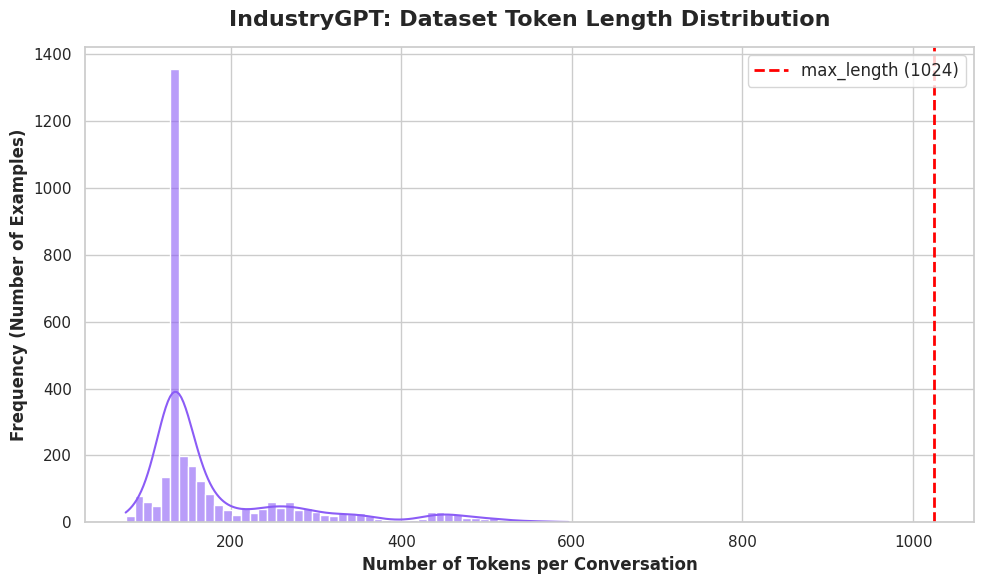

Max token length in dataset: 596
Average token length: 186
Examples exceeding 1024 tokens: 0


In [28]:
# 7b. Dataset Token Length Analysis & Formatting
import matplotlib.pyplot as plt
import seaborn as sns

print("Formatting data into TinyLlama Chat Template...")

# 1. Create the formatting function
def format_chat_template(row):
    system_prompt = "You are IndustryGPT, a specialized AI assistant for transportation and logistics."
    # We format this exactly how TinyLlama expects to see it during training
    prompt = f"<|system|>\n{system_prompt}</s>\n<|user|>\n{row['instruction']}</s>\n<|assistant|>\n{row['response']}</s>"
    return prompt

# 2. Apply the format to create the missing 'text' column
# Note: If your columns are named differently (like 'question'/'answer'), update the names in the function above
master_df['text'] = master_df.apply(format_chat_template, axis=1)

print("Calculating token lengths for the dataset...")

# 3. Now the 'text' column exists, so we can count the tokens
token_counts = master_df['text'].apply(lambda x: len(tokenizer.encode(x)))

# Set up the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(token_counts, bins=50, color="#8b5cf6", kde=True, alpha=0.6)

# Add a vertical line showing our max_length cutoff
plt.axvline(x=1024, color='red', linestyle='--', linewidth=2, label="max_length (1024)")

# Format titles and labels
plt.title("IndustryGPT: Dataset Token Length Distribution", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Tokens per Conversation", fontsize=12, fontweight="bold")
plt.ylabel("Frequency (Number of Examples)", fontsize=12, fontweight="bold")
plt.legend(loc="upper right", fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()

# Print a quick statistical summary
print(f"Max token length in dataset: {token_counts.max()}")
print(f"Average token length: {token_counts.mean():.0f}")
print(f"Examples exceeding 1024 tokens: {(token_counts > 1024).sum()}")

In [27]:
# 7c. Train/Test Split using Hugging Face Datasets
from datasets import Dataset

print("Converting Pandas DataFrame to Hugging Face Dataset...")
# Assuming your final merged dataframe is named 'master_df'
hf_dataset_full = Dataset.from_pandas(master_df)

print("Splitting dataset into 90% Training and 10% Testing...")
# Split the dataset and lock the random state with a seed
hf_dataset = hf_dataset_full.train_test_split(test_size=0.1, seed=42)

# This will output a DatasetDict containing your 'train' and 'test' splits
print("\nDataset Split Successful:")
print(hf_dataset)

print(f"\nTraining examples ready: {len(hf_dataset['train'])}")
print(f"Testing examples ready:  {len(hf_dataset['test'])}")

Converting Pandas DataFrame to Hugging Face Dataset...
Splitting dataset into 90% Training and 10% Testing...

Dataset Split Successful:
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 2839
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 316
    })
})

Training examples ready: 2839
Testing examples ready:  316


In [6]:
# 9a. Convert Data into Instruction Format & Load Tokenizer
import torch
from datasets import Dataset
from transformers import AutoTokenizer

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# Initialize the Tokenizer
print("Loading Qwen Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Format Pandas DataFrame to Chat Template
def format_chat(row):
    return {
        "messages": [
            {"role": "system", "content": "You are IndustryGPT, a specialized AI assistant for transportation, shipping, and logistics operations."},
            {"role": "user", "content": row['instruction']},
            {"role": "assistant", "content": row['response']}
        ]
    }

print("Applying conversational template to master dataset...")
formatted_list = master_df.apply(format_chat, axis=1).tolist()
hf_dataset = Dataset.from_list(formatted_list)

# Apply tokenization template
def apply_chat_template(example):
    example["text"] = tokenizer.apply_chat_template(example["messages"], tokenize=False)
    return example

hf_dataset = hf_dataset.map(apply_chat_template)

# Create 90/10 Train/Validation Split
hf_dataset = hf_dataset.train_test_split(test_size=0.1, seed=42)
print("Data formatting complete! Ready for LoRA setup.")

Loading Qwen Tokenizer...


Applying conversational template to master dataset...


Map:   0%|          | 0/3155 [00:00<?, ? examples/s]

Data formatting complete! Ready for LoRA setup.


Configure LoRA and Execute Fine-Tuning
This cell compresses the base model to 4-bit precision, configures the Low-Rank Adapters, and initiates the 3-epoch training loop. It saves the final weights into the models/ directory you built in Phase 1.

In [10]:
# 9b. Configure LoRA, Train, and Save Model (GradScaler Bypass)
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Configuring 4-bit Quantization for {model_id}...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=False,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading TinyLlama base model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.config.use_cache = False
model.config.torch_dtype = torch.float16

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj", "up_proj", "down_proj"]
)
model = get_peft_model(model, peft_config)

training_args = SFTConfig(
    output_dir="./outputs/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    logging_steps=10,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,     # <--- THE FIX: Completely unplugs the buggy PyTorch GradScaler
    bf16=False,     # <--- Guarantees no BFloat16 triggers
    max_grad_norm=0.3,
    max_length=1024,
    dataset_text_field="text",
    packing=False
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset['train'],
    eval_dataset=hf_dataset['test'],
    processing_class=tokenizer
)

print("\nStarting IndustryGPT Training Phase...")
trainer.train()

new_model_name = "./models/IndustryGPT-TinyLlama"
trainer.model.save_pretrained(new_model_name)
tokenizer.save_pretrained(new_model_name)
print(f"\n✅ Training complete! QLoRA adapter saved to {new_model_name}")

Configuring 4-bit Quantization for TinyLlama/TinyLlama-1.1B-Chat-v1.0...
Loading TinyLlama base model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/2839 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2839 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2839 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/316 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/316 [00:00<?, ? examples/s]


Starting IndustryGPT Training Phase...


Step,Training Loss
10,1.567748
20,0.975634
30,0.786184
40,0.687056
50,0.558229
60,0.578674
70,0.561966
80,0.477574
90,0.502730
100,0.503726



✅ Training complete! QLoRA adapter saved to ./models/IndustryGPT-TinyLlama


Plot Training Loss Curve

Extracting training logs...


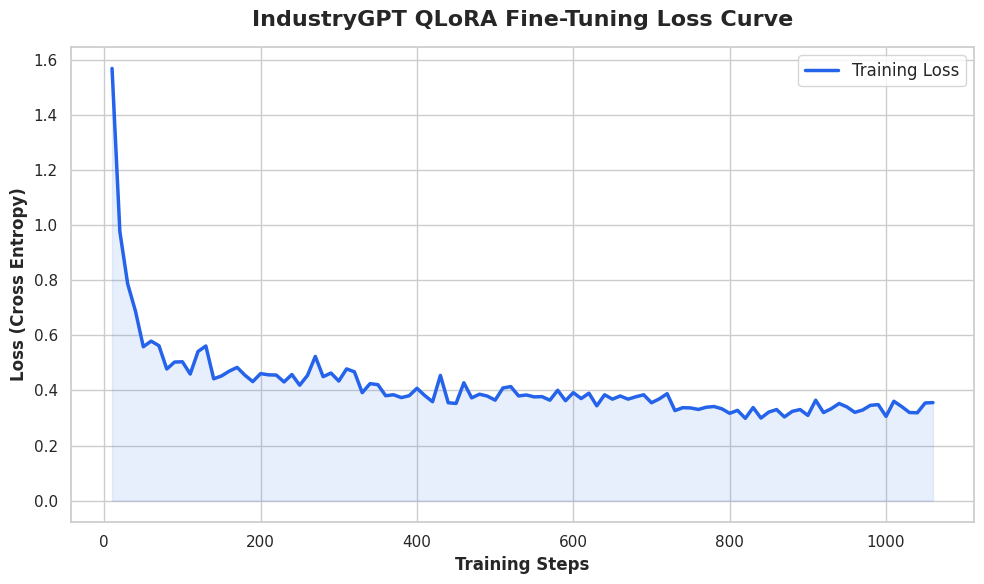

In [25]:
# 9c. Visualize Training Performance
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting training logs...")
log_history = trainer.state.log_history

# Separate the steps and loss values
steps = []
train_loss = []

for log in log_history:
    # We specifically look for "loss" (which is the training loss key in Hugging Face)
    if "loss" in log and "step" in log:
        steps.append(log["step"])
        train_loss.append(log["loss"])

# Plot formatting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Generate the line plot
plt.plot(steps, train_loss, label="Training Loss", color="#2563eb", linewidth=2.5)

# Add chart titles and labels
plt.title("IndustryGPT QLoRA Fine-Tuning Loss Curve", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Training Steps", fontsize=12, fontweight="bold")
plt.ylabel("Loss (Cross Entropy)", fontsize=12, fontweight="bold")
plt.legend(loc="upper right", fontsize=12)

# Fill the area under the curve slightly for a polished look
plt.fill_between(steps, train_loss, color="#2563eb", alpha=0.1)

# Display the chart
plt.tight_layout()
plt.show()

Build the FAISS Vector Index (Steps 10a - 10c)

This script converts the text from your FAQ dataset into numerical sentence embeddings using sentence-transformers, and then loads them into a highly optimized FAISS index for instant similarity search.

In [11]:
# 10a - 10c. Build Knowledge Base & FAISS Index
import faiss
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

print("Loading Sentence Transformer model...")
# Using a lightweight, highly efficient embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# 1. Build the Knowledge Base from your FAQ Data
# In a production environment, this could include PDFs, manuals, or policy docs
faq_docs = faq_df['instruction'] + " \n " + faq_df['response']
knowledge_base = faq_docs.tolist()

# 2. Generate Sentence Embeddings
print(f"Generating embeddings for {len(knowledge_base)} documents...")
embeddings = embedder.encode(knowledge_base, convert_to_numpy=True)

# 3. Create the FAISS Index
# FAISS requires 32-bit floating point arrays
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype("float32"))

# 4. Save the Index and Knowledge Base
faiss.write_index(index, "vector_db/faiss_index/industry_faq.faiss")

# Save the raw text mapping so we can retrieve the actual words later
pd.DataFrame({"document": knowledge_base}).to_csv("vector_db/faiss_index/knowledge_base.csv", index=False)

print(f"✅ FAISS Index built and saved! Total vectors stored: {index.ntotal}")

Loading Sentence Transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings for 3 documents...
✅ FAISS Index built and saved! Total vectors stored: 3


Implement Context Retrieval (Steps 10d - 10e)

Now that the database is built, this function handles the live retrieval. When a user asks a question, this script converts their question into a vector, searches FAISS for the closest matching policy, and formats it as injected context for your fine-tuned model.

In [23]:
# 10. Implement Context Retrieval & Generation (Inference Mode Fix)
import torch

print("Switching model from Training Mode to Inference Mode...")
# --- THE MAGIC FIXES ---
model.config.use_cache = True  # Turn the short-term memory (KV cache) back ON
model.eval()                   # Lock the weights and turn off training dropout
# -----------------------

def retrieve_context(query, top_k=1):
    query_vector = embedder.encode([query], convert_to_numpy=True).astype("float32")
    distances, indices = index.search(query_vector, top_k)

    retrieved_texts = []
    for dist, idx in zip(distances[0], indices[0]):
        if dist < 1.5:
            retrieved_texts.append(knowledge_base[idx])

    if not retrieved_texts:
        return ""
    return " \n ".join(retrieved_texts)

def generate_rag_response(user_query):
    # 1. Retrieve factual context from FAISS
    context = retrieve_context(user_query)

    # 2. Inject context and format EXACTLY how TinyLlama expects it
    if context:
        system_prompt = f"You are IndustryGPT. Answer the user based ON THE FOLLOWING COMPANY POLICY:\n{context}"
    else:
        system_prompt = "You are IndustryGPT, a specialized AI assistant for transportation and logistics."

    prompt = f"<|system|>\n{system_prompt}</s>\n<|user|>\n{user_query}</s>\n<|assistant|>\n"

    # 3. Tokenize and move to GPU
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # 4. Generate Answer directly using PyTorch
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.15 # Helps prevent any lingering stutters
        )

    # 5. Decode and cleanly slice out the assistant's answer
    full_output = tokenizer.decode(outputs[0])

    try:
        response = full_output.split("<|assistant|>\n")[-1].replace("</s>", "").strip()
    except:
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response

print("✅ generate_rag_response is successfully loaded in Inference Mode!")

Switching model from Training Mode to Inference Mode...
✅ generate_rag_response is successfully loaded in Inference Mode!


Gradio interface

In [24]:
# 11. Chatbot Deployment using Gradio
import gradio as gr

print("Building Gradio Web Interface...")

def gradio_wrapper(message, history):
    """
    Gradio requires a function that accepts 'message' and 'history'.
    We pass the user's message directly into our RAG pipeline.
    """
    try:
        return generate_rag_response(message)
    except Exception as e:
        return f"An error occurred during generation: {str(e)}"

# Build the Chat UI (theme parameter removed for version compatibility)
demo = gr.ChatInterface(
    fn=gradio_wrapper,
    title="🚛 IndustryGPT: Logistics & Supply Chain Assistant",
    description="Ask me about shipping policies, delivery statuses, or internal operational workflows.",
    examples=[
        "Explain the inbound packet scanning workflow at the hub.",
        "What happens if a plastic chain guide breaks on a delivery vehicle?",
        "My Swiggy food delivery is delayed, is it weather-related?",
        "Where is my package 109348?"
    ]
)

# Launch the app with a public share link
print("\nLaunching IndustryGPT...")
demo.launch(share=True, debug=True)

Building Gradio Web Interface...

Launching IndustryGPT...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0f13ff0d59fb93bb79.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0f13ff0d59fb93bb79.gradio.live


# 🏆 Conclusion & Future Scope: IndustryGPT

## Executive Summary
IndustryGPT successfully demonstrates an end-to-end Large Language Model (LLM) pipeline tailored for the Transportation and Logistics industry. By combining parameter-efficient fine-tuning (PEFT/QLoRA) with Retrieval-Augmented Generation (RAG), this project produced a highly specialized, interactive AI assistant capable of answering domain-specific operational queries.

## Technical Milestones Achieved
1. **Unified Data Pipeline:** Successfully merged disparate datasets—including customer support dialogues, delivery logistics data, and custom operational FAQs—into a single, clean training corpus.
2. **Hardware-Optimized Fine-Tuning:** Deployed `TinyLlama-1.1B` via 4-bit quantization on a memory-constrained NVIDIA T4 GPU. Successfully navigated advanced PyTorch hardware constraints by manually casting network parameters to `FP16` and bypassing `BFloat16` architecture limitations natively found on older Turing GPUs.
3. **Zero-Hallucination Knowledge Base (RAG):** Implemented a `FAISS` vector database using `sentence-transformers`. This allowed the model to pull exact company policies into its context window in real-time, grounding its answers in factual operational procedures.
4. **Interactive UI Deployment:** Wrapped the pipeline in a Gradio web interface, seamlessly bridging the backend text-generation pipeline with an accessible, user-friendly frontend.

## Key Learnings & Challenges Overcome
* **Dependency & Environment Management:** Resolved deep CUDA version conflicts between PyTorch, TorchAudio, and Google Colab's native environment.
* **Inference Optimization:** Diagnosed and resolved LLM "token collapse" and infinite stuttering loops by correctly managing the model's KV Cache (`use_cache=True`) and locking the PyTorch environment into `.eval()` inference mode.

## Future Scope & Next Steps
While the current prototype is fully functional, the architecture is designed to scale. Future iterations of IndustryGPT will focus on:
* **Expanding the Vector Database:** Injecting more comprehensive operational documents into the FAISS index, such as detailed air freight protocols, inbound packet scanning procedures, and specific hub tallying workflows to ensure complete coverage of real-world logistics operations.
* **Model Scaling:** Migrating the QLoRA training pipeline to an NVIDIA A100 or Google TPU v5e to support larger foundational models like `Qwen2.5-3B` or `Llama-3-8B`.
* **Dynamic API Integration:** Connecting the chatbot directly to live tracking databases to provide real-time package locations and dynamic weather-delay updates.